In [1]:
import machinevisiontoolbox as mv
import matplotlib.pyplot as plt
import spatialmath as sm
import numpy as np

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
cam = mv.CentralCamera.Default()
cam

           Name: default perspective camera [CentralCamera]
     pixel size: 1e-05 x 1e-05
     image size: 1000 x 1000
           pose: t = 0, 0, 0; rpy/yxz = 0°, 0°, 0°
   principal pt: [500. 500.]
   focal length: [0.008 0.008]

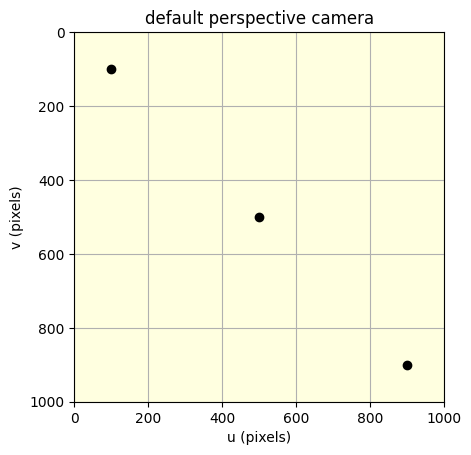

array([[100, 500, 900],
       [100, 500, 900]])

In [3]:
# example plotting (2d point in image plane)
p1 = np.array([[100, 100]]).T
p2 = np.array([[500, 500]]).T
p3 = np.array([[900, 900]]).T
pixel_point = np.hstack((p1, p2, p3))
cam.plot_point(pixel_point)

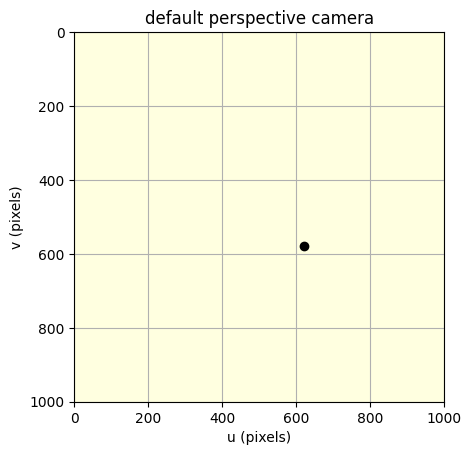

array([[620.],
       [580.]])

In [4]:
# example 3D point projection on image plane
img_plane_point = cam.project_point((0.3, 0.2, 2.0))
cam.plot_point(img_plane_point)

### Visual servoing - EXP (starts from here)

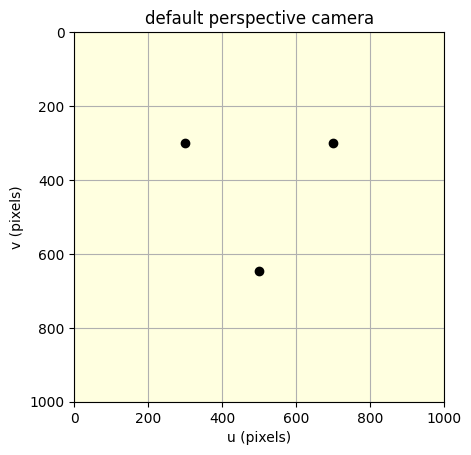

array([[300, 700, 500],
       [300, 300, 646]])

In [5]:
# three points for visual servoing (NOTE: do not use this)
tar_p1 = np.array([[300, 300]]).T
tar_p2 = np.array([[700, 300]]).T
tar_p3 = np.array([[500, 646]]).T
tar_pixel_point = np.hstack((tar_p1, tar_p2, tar_p3))
cam.plot_point(tar_pixel_point)

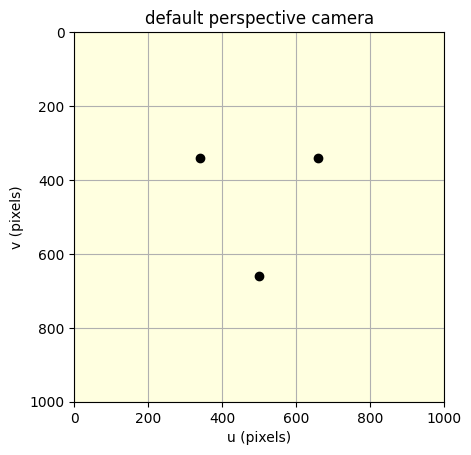

In [ ]:
wrld_p1 = np.array([[-0.2, -0.2, 1]]).T
wrld_p2 = np.array([[0.2, -0.2, 1]]).T
wrld_p3 = np.array([[0.0, 0.2, 1]]).T
wrld_points = np.hstack((wrld_p1, wrld_p2, wrld_p3))
target = cam.plot_point(wrld_points)

In [129]:
# define camera pose
Cpose = sm.SE3(0.3,0,0)
Cpose *= sm.SE3.Rz(45, unit='deg')

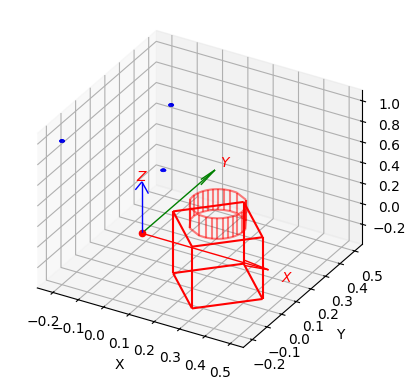

In [130]:
cam.plot(scale=0.5, pose=Cpose)
sm.base.plot_sphere(radius=0.01, centre=wrld_p1, filled=True, facecolor='b')
sm.base.plot_sphere(radius=0.01, centre=wrld_p2, filled=True, facecolor='b')
sm.base.plot_sphere(radius=0.01, centre=wrld_p3, filled=True, facecolor='b')
sm.SE3(0,0,0).plot(length=0.5, style='rgb')
plt.show()

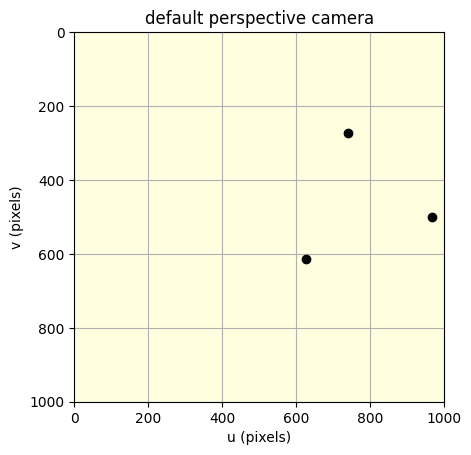

In [131]:
current = cam.plot_point(wrld_points, objpose=Cpose)
plt.show()

In [132]:
print("Current points:\n", current)
print("Target points:\n", target)

Current points:
 [[740.         966.27416998 626.86291501]
 [273.72583002 500.         613.13708499]]
Target points:
 [[340. 660. 500.]
 [340. 340. 660.]]


In [133]:
# computing pixel velocity and required camera velocity
gainLambda = 0.5
tempVel = gainLambda * (current - target)
pixelVel = np.empty((6,1))
# reshape
idx = 0
for i in range(3):
    pixelVel[idx] = tempVel[0, i]; idx+=1
    pixelVel[idx] = tempVel[1, i]; idx+=1
print(f"Computed pixel velocity:\n{pixelVel}")

Computed pixel velocity:
[[200.        ]
 [-33.13708499]
 [153.13708499]
 [ 80.        ]
 [ 63.43145751]
 [-23.43145751]]


In [134]:
# compute points jacobian (6x6) - 3 points
pointsJacob = cam.visjac_p(current, 1)
invPointsJacob = np.linalg.pinv(pointsJacob)
print(f"Image points Jacobian:\n{pointsJacob}\n")
print(f"Inverse of Image points Jacobian:\n{invPointsJacob}")

Image points Jacobian:
[[ -800.             0.           240.           -67.88225099
   -872.          -226.27416998]
 [    0.          -800.          -226.27416998   864.
     67.88225099  -240.        ]
 [ -800.             0.           466.27416998     0.
  -1071.76450199     0.        ]
 [    0.          -800.             0.           800.
      0.          -466.27416998]
 [ -800.             0.           126.86291501    17.9411255
   -820.11774901   113.13708499]
 [    0.          -800.           113.13708499   816.
    -17.9411255   -126.86291501]]

Inverse of Image points Jacobian:
[[ 9.11927317e-03  1.35786998e-02  5.68689110e-03 -1.59578035e-02
  -1.60561643e-02  2.37910364e-03]
 [-3.21675234e-02 -2.24000609e-02  1.89563037e-03  3.94695504e-02
   3.02718930e-02 -1.83194895e-02]
 [-8.04805874e-03 -1.08129847e-02 -1.16990210e-03  1.20423543e-02
   9.21796084e-03 -1.22936963e-03]
 [-3.00946593e-02 -2.02014565e-02  1.89563037e-03  3.61966014e-02
   2.81990290e-02 -1.59951449e-02]


In [135]:
# compute camera velocity using points jacobian
camVel = np.round(invPointsJacob @ pixelVel, 5)
camVel

array([[-0.10607],
       [ 0.10607],
       [ 0.14645],
       [ 0.     ],
       [-0.     ],
       [-0.35355]])

In [128]:
# integrate the velocity to positions and update the target camera pose
Cpose.t[0] -= 0.15
Cpose

   1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         
